# 02 — Univariate analysis

Examines amount skew, categorical concentration, and missingness in the source transaction table.

In [1]:
# Setup
from pathlib import Path
import logging, random
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
random.seed(42); np.random.seed(42)
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
paths = [p for root in (Path('/kaggle/input'), Path('data/original')) if root.exists() for p in root.rglob('transactions.csv')]
if not paths: raise FileNotFoundError('Upload the source bundle to Kaggle Input or data/original.')
transactions = pd.read_csv(paths[0])
amount = transactions['amount_local_npr'].astype(float)


,amount_local_npr
count,1.002220e+05
mean,1.769235e+06
std,5.005345e+06
min,3.740000e+00
1%,7.835871e+03
25%,3.932731e+05
50%,1.238980e+06
75%,2.113782e+06
95%,4.335848e+06
99%,9.221886e+06


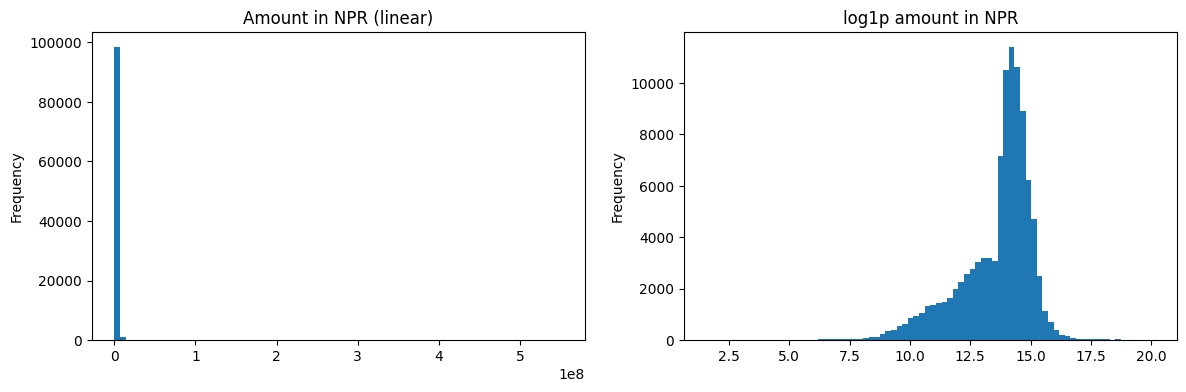


Payment_type


,count
Payment_type,
ACH,21658
Credit card,21299
Debit card,21287
Cheque,21058
Cross-border,10166
Cash Withdrawal,3108
Cash Deposit,1646



transmode_code


,count
transmode_code,
J,42586
P,21658
E,21058
F,10166
A,4754



Payment_currency


,count
Payment_currency,
UK pounds,95871
Euro,1527
US dollar,425
Yen,352
Albanian lek,318
Swiss franc,304
Moroccan dirham,262
Pakistani rupee,218
Mexican Peso,208



Sender_bank_location


,count
Sender_bank_location,
UK,96764
Italy,340
USA,339
Austria,286
Spain,282
Netherlands,272
Japan,268
Albania,247
Switzerland,228


In [2]:
display(amount.describe(percentiles=[.01, .25, .5, .75, .95, .99]).to_frame('amount_local_npr'))
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
amount.plot.hist(bins=80, ax=axes[0], title='Amount in NPR (linear)')
np.log1p(amount).plot.hist(bins=80, ax=axes[1], title='log1p amount in NPR')
plt.show()
for column in ['Payment_type', 'transmode_code', 'Payment_currency', 'Sender_bank_location']:
    print(f'\n{column}')
    display(transactions[column].value_counts(dropna=False).head(15).rename('count').to_frame())


## Conclusion
The amount distribution should be reported on both linear and log scales. Rare categories must be quantified before later mapping or generation choices.